# LSTM Forecasting

Capstone Project - Time Series Analysis 2026

## 0. Imports & Config

In [1]:
import os, warnings
warnings.filterwarnings('ignore')
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

np.random.seed(42)
tf.random.set_seed(42)

plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

os.makedirs('../outputs/forecasts', exist_ok=True)
os.makedirs('../outputs/plots', exist_ok=True)

print('Imports OK.')

I0000 00:00:1778626349.882278   79896 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1778626349.897646   79896 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1778626361.908036   79896 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1778626361.913583   79896 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


Imports OK.


In [2]:
import sys
sys.path.append('..')

from config import (
    tickers as TICKERS,
    start_date as START_DATE,
    end_date as END_DATE,
    train_end as TRAIN_END,
    test_start as TEST_START,
    forecast_horizon as FORECAST_HORIZON,
    virtual_capital as TOTAL_CAPITAL,
    lstm_window as LSTM_WINDOW,
    random_seed as RANDOM_SEED,
)

TICKER_LIST = list(TICKERS.values())
SECTOR_MAP = {v: k for k, v in TICKERS.items()}
EPOCHS = 60
BATCH_SIZE = 32


---
## 1. Load Data

In [3]:
train_close = pd.read_csv('../data/processed/train_close.csv', index_col=0, parse_dates=True)
test_close  = pd.read_csv('../data/processed/test_close.csv',  index_col=0, parse_dates=True)
full_close  = pd.concat([train_close, test_close])

print(f'Train: {train_close.index[0].date()} → {train_close.index[-1].date()}  ({len(train_close)} rows)')
print(f'Test : {test_close.index[0].date()}  → {test_close.index[-1].date()}  ({len(test_close)} rows)')

Train: 2021-01-01 → 2025-06-30  (1110 rows)
Test : 2025-07-01  → 2025-12-30  (125 rows)


---
## 2. Metric Helper Functions

In [4]:
def mape(actual, predicted):
    actual, predicted = np.array(actual), np.array(predicted)
    mask = actual != 0
    return np.mean(np.abs((actual[mask] - predicted[mask]) / actual[mask])) * 100

def rmse(actual, predicted):
    return np.sqrt(np.mean((np.array(actual) - np.array(predicted)) ** 2))

def directional_accuracy(actual, predicted):
    ad  = np.sign(np.diff(np.array(actual)))
    pd_ = np.sign(np.diff(np.array(predicted)))
    return (np.sum(ad == pd_) / len(ad)) * 100

print('Metrics ready.')

Metrics ready.


---
## 3. Feature Engineering

Instead of feeding raw prices, we give the LSTM four signals:

| Feature | What it captures |
|---------|-----------------|
| **Log-return** | Day-over-day price change (stationary) |
| **RSI(14)** | Momentum — overbought / oversold |
| **MACD** | Trend direction and momentum cross |
| **20-day vol** | Short-term risk level |

Using log-returns as the primary target (instead of raw price) makes the LSTM's
job easier — returns are closer to stationary, so the model doesn't have to learn
a long upward drift before it can learn patterns.

In [5]:
def compute_features(price_series):
    df = pd.DataFrame({'close': price_series})
    df['log_ret']      = np.log(df['close'] / df['close'].shift(1))
    delta = df['close'].diff()
    gain  = delta.clip(lower=0).rolling(14).mean()
    loss  = (-delta.clip(upper=0)).rolling(14).mean()
    df['rsi_14']       = 100 - (100 / (1 + gain / (loss + 1e-9)))
    ema12 = df['close'].ewm(span=12, adjust=False).mean()
    ema26 = df['close'].ewm(span=26, adjust=False).mean()
    df['macd']         = ema12 - ema26
    df['volatility_20']= df['log_ret'].rolling(20).std()
    df.dropna(inplace=True)
    return df

# Include 'close' in features so the scaler covers price scale
FEATURE_COLS = ['close', 'log_ret', 'rsi_14', 'macd', 'volatility_20']
CLOSE_IDX    = FEATURE_COLS.index('close')   # target column index
print(f'Features: {FEATURE_COLS}')
print(f'Target  : FEATURE_COLS[{CLOSE_IDX}] = close (next-day price)')

Features: ['close', 'log_ret', 'rsi_14', 'macd', 'volatility_20']
Target  : FEATURE_COLS[0] = close (next-day price)


---
## 4. Sequence Builder

In [6]:
def create_sequences(scaled_array, window, target_col):
    """
    X: (samples, window, n_features)
    y: next-day value of target_col (scaled close price)
    """
    X, y = [], []
    for i in range(window, len(scaled_array)):
        X.append(scaled_array[i-window : i])
        y.append(scaled_array[i, target_col])
    return np.array(X), np.array(y)

print(f'Window = {LSTM_WINDOW} days, target = next-day close (scaled)')

Window = 60 days, target = next-day close (scaled)


---
## 5. LSTM Architecture

128-unit layers (up from 64) + ReduceLROnPlateau to avoid getting stuck.

In [7]:
def build_lstm(input_shape):
    model = Sequential([
        LSTM(128, return_sequences=True, input_shape=input_shape),
        Dropout(0.2),
        LSTM(64, return_sequences=False),
        Dropout(0.2),
        Dense(32, activation='relu'),
        Dense(1)
    ])
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return model

early_stop = EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True, verbose=0)
reduce_lr  = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=0)

print('LSTM builder ready.')

LSTM builder ready.


---
## 6. Train, Evaluate & Forecast per Stock

In [8]:
lstm_models     = {}
lstm_metrics    = []
lstm_test_preds = {}
lstm_pred_rows = []
price_scalers   = {}

for ticker in TICKER_LIST:
    print(f'\n{"="*55}')
    print(f'LSTM for: {ticker} ({SECTOR_MAP[ticker]})')
    print('='*55)

    # Full feature df (needed for aligned indexing)
    full_feat  = compute_features(full_close[ticker].dropna())
    n_train_feat = len(compute_features(train_close[ticker].dropna()))

    train_feat = full_feat.iloc[:n_train_feat]
    test_feat  = full_feat.iloc[n_train_feat:]

    # Scaler fit on train only
    scaler = MinMaxScaler(feature_range=(0, 1))
    train_scaled = scaler.fit_transform(train_feat[FEATURE_COLS].values)
    test_scaled  = scaler.transform(test_feat[FEATURE_COLS].values)
    price_scalers[ticker] = scaler

    # Sequences from training data only
    X_train, y_train = create_sequences(train_scaled, LSTM_WINDOW, CLOSE_IDX)

    val_size = max(1, int(len(X_train) * 0.1))
    X_val, y_val = X_train[-val_size:], y_train[-val_size:]
    X_tr,  y_tr  = X_train[:-val_size], y_train[:-val_size]

    model = build_lstm((LSTM_WINDOW, len(FEATURE_COLS)))
    history = model.fit(X_tr, y_tr,
                        epochs=EPOCHS, batch_size=BATCH_SIZE,
                        validation_data=(X_val, y_val),
                        callbacks=[early_stop, reduce_lr],
                        verbose=0)
    lstm_models[ticker] = model
    print(f'  Trained {len(history.history["loss"])} epochs  |  '
          f'best val_loss: {min(history.history["val_loss"]):.6f}')

    # Evaluation: slide window over ACTUAL data — no compounding
    all_scaled = np.concatenate([train_scaled, test_scaled], axis=0)
    n_train_s  = len(train_scaled)
    preds_scaled = []

    for i in range(len(test_scaled)):
        start = n_train_s + i - LSTM_WINDOW
        window_data = all_scaled[start : start + LSTM_WINDOW]
        pred_s = model.predict(
            window_data.reshape(1, LSTM_WINDOW, len(FEATURE_COLS)),
            verbose=0
        )[0, 0]
        preds_scaled.append(pred_s)

    # Inverse-transform: reconstruct full feature row, invert, extract close
    dummy = np.zeros((len(preds_scaled), len(FEATURE_COLS)))
    dummy[:, CLOSE_IDX] = preds_scaled
    preds_price = scaler.inverse_transform(dummy)[:, CLOSE_IDX]
    lstm_test_preds[ticker] = preds_price

    actual_prices = test_feat['close'].values
    for dt, actual_val, pred_val in zip(test_feat.index, actual_prices, preds_price):
        lstm_pred_rows.append({
            'Date': dt,
            'Stock': ticker,
            'Sector': SECTOR_MAP[ticker],
            'Actual': actual_val,
            'Predicted': pred_val
        })
    min_len = min(len(actual_prices), len(preds_price))

    m = {
        'Stock'      : ticker,
        'Sector'     : SECTOR_MAP[ticker],
        'MAPE (%)'   : round(mape(actual_prices[:min_len], preds_price[:min_len]), 4),
        'RMSE'       : round(rmse(actual_prices[:min_len], preds_price[:min_len]), 4),
        'Dir Acc (%)': round(directional_accuracy(actual_prices[:min_len], preds_price[:min_len]), 2)
    }
    lstm_metrics.append(m)
    print(f'  MAPE: {m["MAPE (%)"]:.2f}%  |  RMSE: {m["RMSE"]:.2f}  |  Dir Acc: {m["Dir Acc (%)"]:.1f}%')

pd.DataFrame(lstm_pred_rows).to_csv('../outputs/forecasts/lstm_test_predictions.csv', index=False)
print('\nAll LSTM models done.')


LSTM for: HDFCBANK.NS (Banking)


E0000 00:00:1778626362.971592   79896 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


  Trained 13 epochs  |  best val_loss: 0.002586
  MAPE: 1.32%  |  RMSE: 15.28  |  Dir Acc: 46.0%

LSTM for: INFY.NS (IT)
  Trained 7 epochs  |  best val_loss: 0.003330
  MAPE: 2.87%  |  RMSE: 50.79  |  Dir Acc: 46.8%

LSTM for: SUNPHARMA.NS (Pharma)
  Trained 19 epochs  |  best val_loss: 0.001287
  MAPE: 1.30%  |  RMSE: 27.98  |  Dir Acc: 47.6%

LSTM for: M&M.NS (Auto)
  Trained 7 epochs  |  best val_loss: 0.002359
  MAPE: 2.31%  |  RMSE: 103.84  |  Dir Acc: 37.1%

LSTM for: HINDUNILVR.NS (FMCG)
  Trained 7 epochs  |  best val_loss: 0.001381
  MAPE: 1.89%  |  RMSE: 58.83  |  Dir Acc: 54.0%

All LSTM models done.


---
## 7. Predicted vs Actual Plots

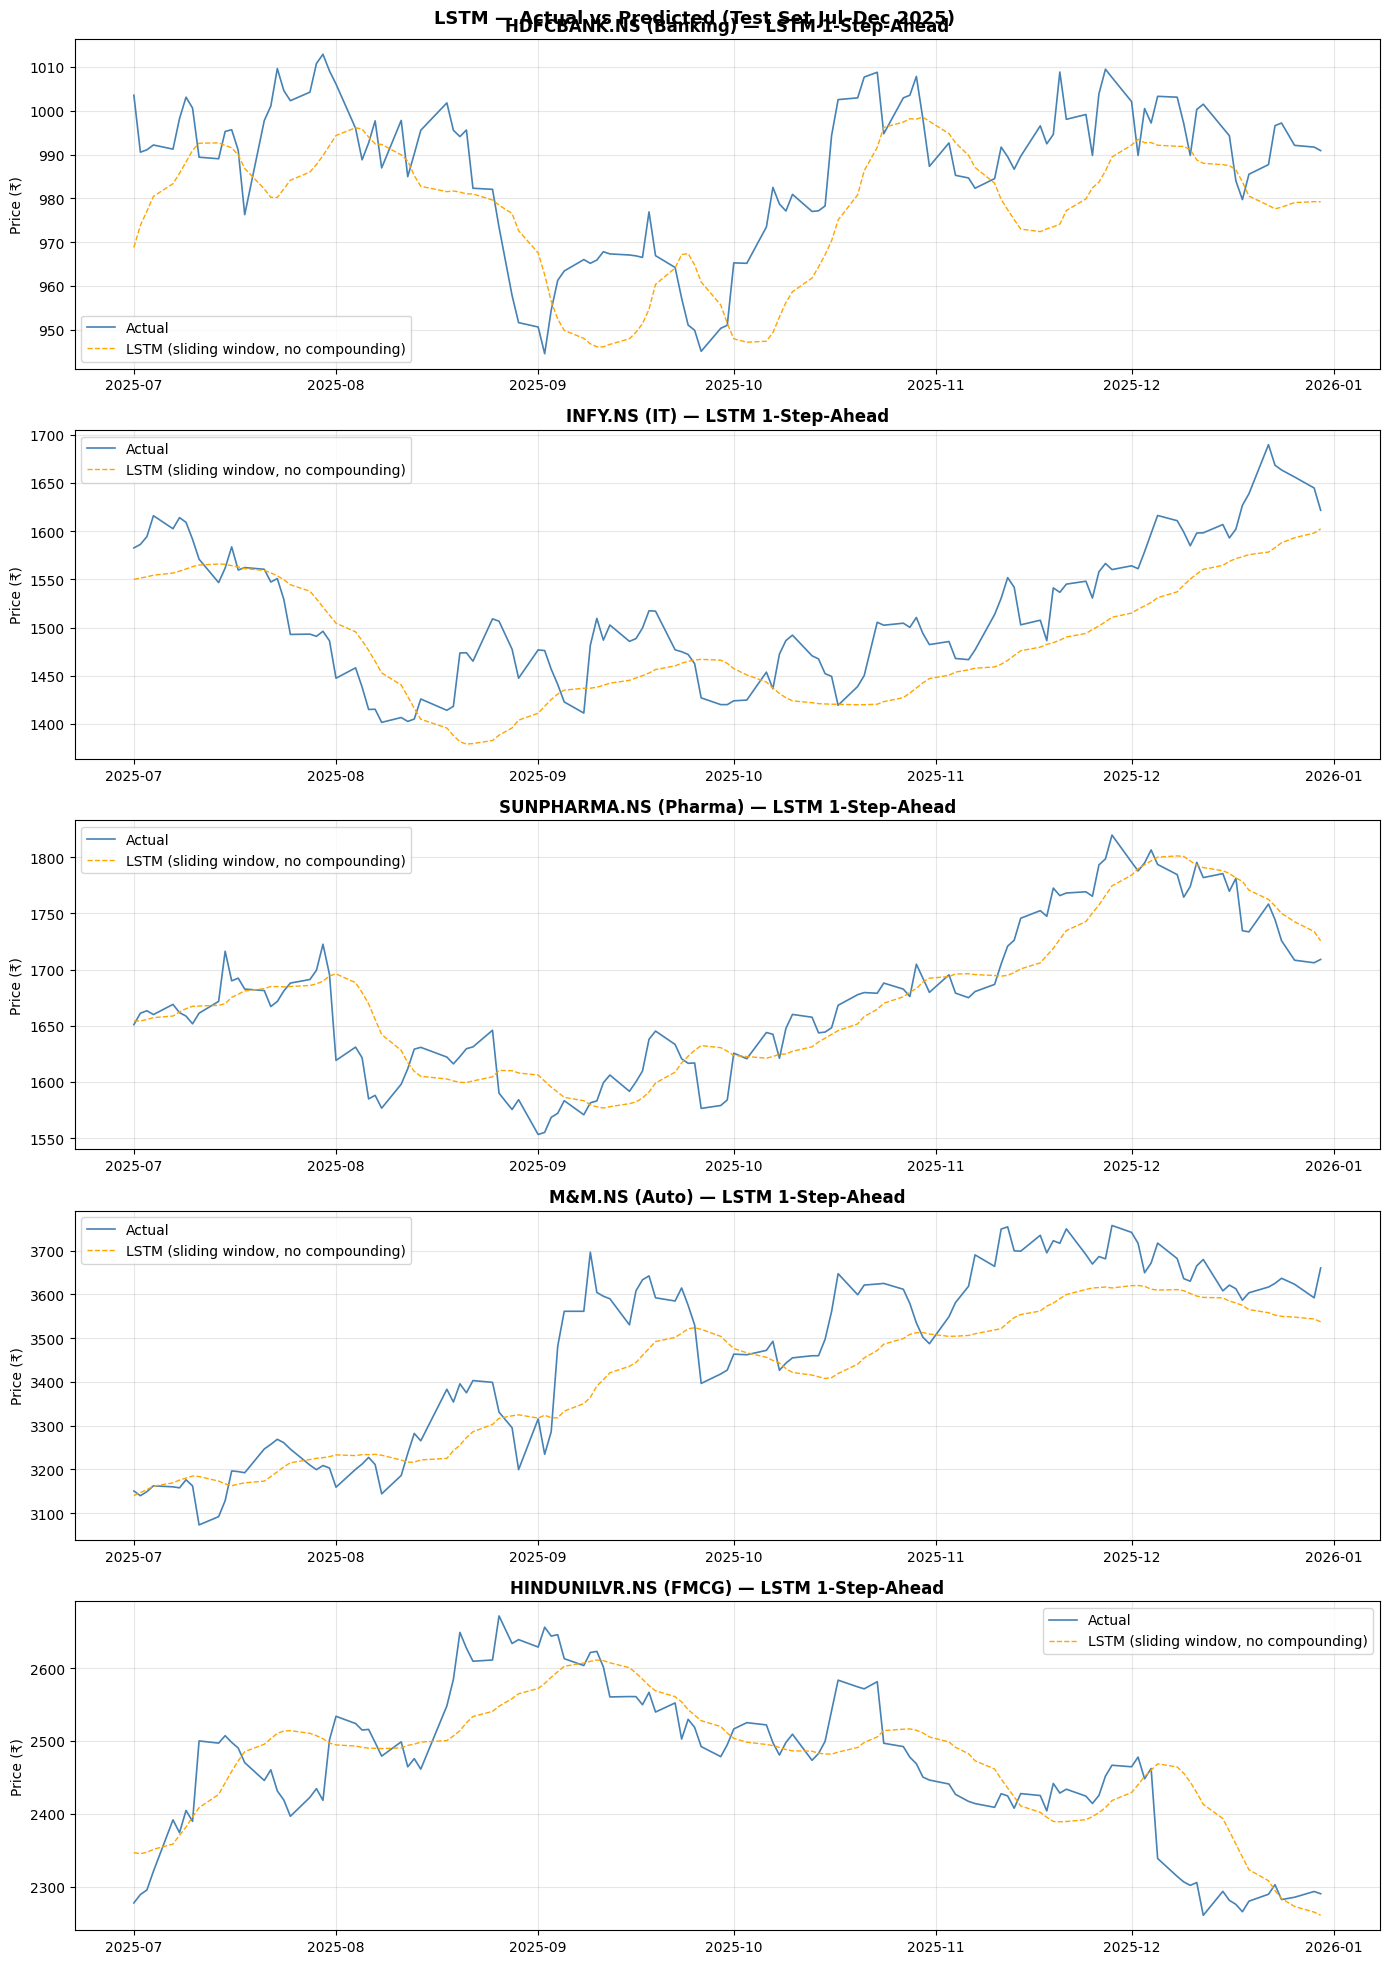

In [9]:
fig, axes = plt.subplots(len(TICKER_LIST), 1, figsize=(14, 4 * len(TICKER_LIST)), sharex=False)

for ax, ticker in zip(axes, TICKER_LIST):
    actual = test_close[ticker].dropna()
    preds  = lstm_test_preds[ticker]
    min_len = min(len(actual), len(preds))

    ax.plot(actual.index[:min_len], actual.values[:min_len],
            label='Actual', linewidth=1.2, color='steelblue')
    ax.plot(actual.index[:min_len], preds[:min_len],
            label='LSTM (sliding window, no compounding)',
            linewidth=1.0, color='orange', linestyle='--')
    ax.set_title(f'{ticker} ({SECTOR_MAP[ticker]}) — LSTM 1-Step-Ahead',
                 fontweight='bold')
    ax.set_ylabel('Price (₹)')
    ax.legend()

plt.suptitle('LSTM — Actual vs Predicted (Test Set Jul–Dec 2025)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/plots/08_lstm_predictions.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 8. Metrics Summary Table (Task 6 input)

In [10]:
metrics_df = pd.DataFrame(lstm_metrics)
print('LSTM Evaluation Metrics — Test Set (Jul–Dec 2025)')
print('='*60)
print(metrics_df.to_string(index=False))
print(f'\nAvg MAPE    : {metrics_df["MAPE (%)"].mean():.2f}%')
print(f'Avg RMSE    : {metrics_df["RMSE"].mean():.2f}')
print(f'Avg Dir Acc : {metrics_df["Dir Acc (%)"].mean():.1f}%')

metrics_df.to_csv('../outputs/forecasts/lstm_metrics.csv', index=False)

LSTM Evaluation Metrics — Test Set (Jul–Dec 2025)
        Stock  Sector  MAPE (%)     RMSE  Dir Acc (%)
  HDFCBANK.NS Banking    1.3185  15.2826        45.97
      INFY.NS      IT    2.8748  50.7852        46.77
 SUNPHARMA.NS  Pharma    1.2989  27.9803        47.58
       M&M.NS    Auto    2.3064 103.8401        37.10
HINDUNILVR.NS    FMCG    1.8876  58.8250        54.03

Avg MAPE    : 1.94%
Avg RMSE    : 51.34
Avg Dir Acc : 46.3%


---
## 9. Live 2-Day Forecast (Beyond Dec 2025)

In [11]:
live_forecasts = []

for ticker in TICKER_LIST:
    scaler   = price_scalers[ticker]
    full_s   = full_close[ticker].dropna()
    last_price = full_s.iloc[-1]

    full_feat = compute_features(full_s)
    full_scaled = scaler.transform(full_feat[FEATURE_COLS].values)

    current_window = list(full_scaled[-LSTM_WINDOW:])
    day_preds_scaled = []

    for _ in range(FORECAST_HORIZON):
        x = np.array(current_window[-LSTM_WINDOW:]).reshape(1, LSTM_WINDOW, len(FEATURE_COLS))
        pred_s = lstm_models[ticker].predict(x, verbose=0)[0, 0]
        day_preds_scaled.append(pred_s)

        # Build next row using prediction as close, carry last row's other features
        next_row = current_window[-1].copy()
        next_row[CLOSE_IDX] = pred_s
        current_window.append(next_row)

    dummy = np.zeros((FORECAST_HORIZON, len(FEATURE_COLS)))
    dummy[:, CLOSE_IDX] = day_preds_scaled
    day_prices = scaler.inverse_transform(dummy)[:, CLOSE_IDX]

    live_forecasts.append({
        'Stock'             : ticker,
        'Sector'            : SECTOR_MAP[ticker],
        'Last Known Price'  : round(last_price, 2),
        'Forecast Day 1'    : round(day_prices[0], 2),
        'Forecast Day 2'    : round(day_prices[1], 2),
        'Pred Return D1 (%)': round((day_prices[0]-last_price)/last_price*100, 3),
        'Pred Return D2 (%)': round((day_prices[1]-last_price)/last_price*100, 3)
    })

live_df = pd.DataFrame(live_forecasts)
print('Live 2-Day LSTM Forecast:')
print(live_df.to_string(index=False))

live_df.to_csv('../outputs/forecasts/lstm_forecasts.csv', index=False)
print('\nSaved lstm_forecasts.csv')

Live 2-Day LSTM Forecast:
        Stock  Sector  Last Known Price  Forecast Day 1  Forecast Day 2  Pred Return D1 (%)  Pred Return D2 (%)
  HDFCBANK.NS Banking             990.9          979.33          978.93              -1.168              -1.208
      INFY.NS      IT            1621.6         1605.76         1608.31              -0.977              -0.820
 SUNPHARMA.NS  Pharma            1709.1         1718.48         1712.60               0.549               0.205
       M&M.NS    Auto            3660.3         3540.27         3543.88              -3.279              -3.181
HINDUNILVR.NS    FMCG            2290.2         2258.42         2256.94              -1.388              -1.452

Saved lstm_forecasts.csv


---
## 10. Summary

In [12]:
print('='*60)
print('NOTEBOOK 03 — LSTM v3 SUMMARY')
print('='*60)
print(f'Architecture : LSTM(128) → Dropout → LSTM(64) → Dense(32) → Dense(1)')
print(f'Input        : ({LSTM_WINDOW} days, {len(FEATURE_COLS)} features)')
print(f'Features     : {FEATURE_COLS}')
print(f'Target       : next-day close price (scaled, no cumsum)')
print(f'Evaluation   : 1-step-ahead sliding window on actual history')
print()
print(metrics_df[['Stock','MAPE (%)','RMSE','Dir Acc (%)']].to_string(index=False))
print()
print('Live 2-day forecast:')
print(live_df[['Stock','Forecast Day 1','Forecast Day 2',
               'Pred Return D1 (%)','Pred Return D2 (%)']].to_string(index=False))

NOTEBOOK 03 — LSTM v3 SUMMARY
Architecture : LSTM(128) → Dropout → LSTM(64) → Dense(32) → Dense(1)
Input        : (60 days, 5 features)
Features     : ['close', 'log_ret', 'rsi_14', 'macd', 'volatility_20']
Target       : next-day close price (scaled, no cumsum)
Evaluation   : 1-step-ahead sliding window on actual history

        Stock  MAPE (%)     RMSE  Dir Acc (%)
  HDFCBANK.NS    1.3185  15.2826        45.97
      INFY.NS    2.8748  50.7852        46.77
 SUNPHARMA.NS    1.2989  27.9803        47.58
       M&M.NS    2.3064 103.8401        37.10
HINDUNILVR.NS    1.8876  58.8250        54.03

Live 2-day forecast:
        Stock  Forecast Day 1  Forecast Day 2  Pred Return D1 (%)  Pred Return D2 (%)
  HDFCBANK.NS          979.33          978.93              -1.168              -1.208
      INFY.NS         1605.76         1608.31              -0.977              -0.820
 SUNPHARMA.NS         1718.48         1712.60               0.549               0.205
       M&M.NS         3540.27    